imports the Python libraries used for audio preprocessing, feature extraction, plotting, and data handling.

In [32]:
import librosa
import numpy as np 
import matplotlib.pyplot as plt 
import os
import pandas as pd
import pydub


# Convert ogg Audio from Telegram into wav format


This cell scans the source audio folder and converts any `.ogg` files into `.wav` files in the cleaned data directory.

In [33]:

# if you have a data in format wav you can skip this step and go to the next cell
# you must run it at least once to convert all the ogg files to wav format

path_in = f"./Data"
path_out = "./Data/Cleaned Data"
for person in os.listdir(path_in):
    person_path = os.path.join(path_in, person)
    for command in os.listdir(person_path):
            command_path = os.path.join(person_path, command)
            if not os.path.exists(path_out):
                os.makedirs(path_out)
            voices = os.listdir(command_path)
            for i , voice   in  enumerate(voices):
                if voice.endswith('.ogg'):
                    file_path = os.path.join(command_path, voice)
                    audio = pydub.AudioSegment.from_ogg(file_path)
                    audio.export(f"{path_out}/{person}_{command}_{i+1}.wav", format="wav")
        

# Extract Features 

Load each cleaned `.wav` file, trims silence, extracts MFCC features, and stores the labels and feature vectors.

In [34]:
cleaned_path = "./Data/Cleaned Data"
Command = []
Person = []
Features = []
voices = os.listdir(cleaned_path)
for i , voice in  enumerate(voices):
    if voice.endswith('.wav'):
        da = voice.split('_')
        Person.append(da[0]) # person name
        Command.append(da[1]) # command name
        audio_path = os.path.join(cleaned_path, voice) # full path
        librosa_audio , sr = librosa.load(audio_path , sr=22050) # load audio file
        removed_silence = librosa.effects.trim(librosa_audio, top_db=30)[0] # remove silence
        
        mfcc_features = librosa.feature.mfcc(y=removed_silence, sr=22050, n_mfcc=17) # extract MFCC features
        mfcc_norm = librosa.util.normalize(mfcc_features) # normalize it
        mfcc_flattened = np.mean(mfcc_norm, axis=1) # flatten it
        Features.append(mfcc_flattened) # finally append it
        
print("Features shape:", np.array(Features).shape)
print("Command shape:", np.array(Command).shape)
print("Person shape:", np.array(Person).shape)
        

Features shape: (220, 17)
Command shape: (220,)
Person shape: (220,)


Scale the extracted features with `StandardScaler` so the models can train on normalized data.

In [35]:
from  sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
Features_Scaled = scaler.fit_transform(Features)

# Command Classification

Split the scaled features into training and test sets for command classification.

In [36]:
Audio_train_c, Audio_test_c, Command_train, Command_test = train_test_split(Features_Scaled, Command, test_size=0.2, random_state=42, stratify=Command)

Train four classifiers for command recognition and compares their test accuracies.

In [37]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import classification_report, confusion_matrix , accuracy_score

# models setup
model_command_SVC = SVC(kernel='linear', C = 1.0 , random_state=42)
model_command_RF = RandomForestClassifier(n_estimators=100, random_state=42)
model_command_KNN = KNeighborsClassifier(n_neighbors=5)
model_command_LR = LogisticRegression(random_state=42)

# models training
model_command_SVC.fit(Audio_train_c, Command_train)
model_command_RF.fit(Audio_train_c, Command_train)
model_command_KNN.fit(Audio_train_c, Command_train)
model_command_LR.fit(Audio_train_c, Command_train)

# models prediction
Audio_pred_SVC = model_command_SVC.predict(Audio_test_c)
Audio_pred_RF = model_command_RF.predict(Audio_test_c)
Audio_pred_KNN = model_command_KNN.predict(Audio_test_c)
Audio_pred_LR = model_command_LR.predict(Audio_test_c)

# models evaluation
accuracy_SVC = accuracy_score(Command_test, Audio_pred_SVC)
accuracy_RF = accuracy_score(Command_test, Audio_pred_RF)
accuracy_KNN = accuracy_score(Command_test, Audio_pred_KNN)
accuracy_LR = accuracy_score(Command_test, Audio_pred_LR)

print("SVC Accuracy:", accuracy_SVC)
print("Random Forest Accuracy:", accuracy_RF)
print("K-Nearest Neighbors Accuracy:", accuracy_KNN)
print("Logistic Regression Accuracy:", accuracy_LR)




SVC Accuracy: 0.8409090909090909
Random Forest Accuracy: 0.9090909090909091
K-Nearest Neighbors Accuracy: 0.8636363636363636
Logistic Regression Accuracy: 0.8409090909090909


Display a confusion matrix for the command classifier predictions.

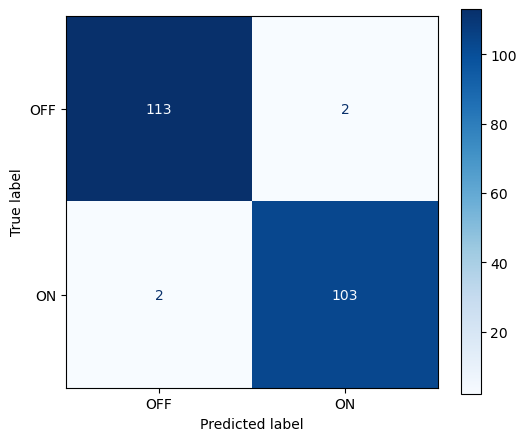

In [38]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

all_command_preds = model_command_RF.predict(Features_Scaled)

cm_command = confusion_matrix(Command, all_command_preds, labels=model_command_RF.classes_)

plt.figure(figsize=(6, 5))
disp_command = ConfusionMatrixDisplay(confusion_matrix=cm_command, display_labels=model_command_RF.classes_)
disp_command.plot(cmap=plt.cm.Blues, ax=plt.gca())
plt.show()



# Person Classification

Split the same features into training and test sets for person recognition.

In [39]:
Audio_train_p, Audio_test_p, Person_train, Person_test = train_test_split(Features_Scaled, Person, test_size=0.2, random_state=42, stratify=Person)


Train four classifiers for person identification and compares their test accuracies.

In [40]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import  accuracy_score


# models setup
model_person_SVC = SVC(kernel='linear', C = 1.0 , random_state=42)
model_person_RF = RandomForestClassifier(n_estimators=100, random_state=42)
model_person_KNN = KNeighborsClassifier(n_neighbors=5)
model_person_LR = LogisticRegression(random_state=42)

# models training
model_person_SVC.fit(Audio_train_p, Person_train)
model_person_RF.fit(Audio_train_p, Person_train)
model_person_KNN.fit(Audio_train_p, Person_train)
model_person_LR.fit(Audio_train_p, Person_train)

# models prediction
Audio_pred_SVC = model_person_SVC.predict(Audio_test_p)
Audio_pred_RF = model_person_RF.predict(Audio_test_p)
Audio_pred_KNN = model_person_KNN.predict(Audio_test_p)
Audio_pred_LR = model_person_LR.predict(Audio_test_p)

# models evaluation
accuracy_SVC = accuracy_score(Person_test, Audio_pred_SVC)
accuracy_RF = accuracy_score(Person_test, Audio_pred_RF)
accuracy_KNN = accuracy_score(Person_test, Audio_pred_KNN)
accuracy_LR = accuracy_score(Person_test, Audio_pred_LR)

print("SVC Accuracy:", accuracy_SVC)
print("Random Forest Accuracy:", accuracy_RF)
print("K-Nearest Neighbors Accuracy:", accuracy_KNN)
print("Logistic Regression Accuracy:", accuracy_LR)




SVC Accuracy: 1.0
Random Forest Accuracy: 1.0
K-Nearest Neighbors Accuracy: 1.0
Logistic Regression Accuracy: 1.0


Display a confusion matrix for the person classifier predictions.

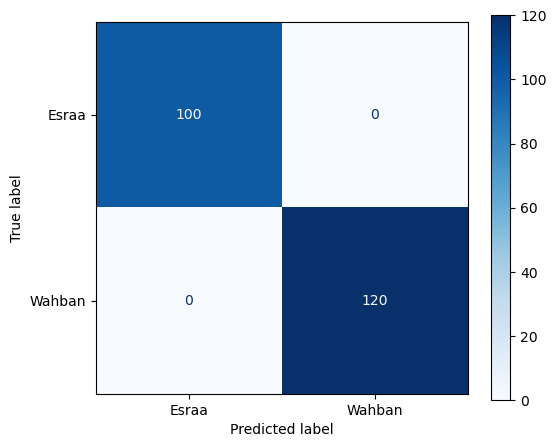

In [41]:
all_person_preds = model_person_RF.predict(Features_Scaled)

cm_person = confusion_matrix(Person, all_person_preds, labels=model_person_RF.classes_)

plt.figure(figsize=(6, 5))
disp_person = ConfusionMatrixDisplay(confusion_matrix=cm_person, display_labels=model_person_RF.classes_)
disp_person.plot(cmap=plt.cm.Blues, ax=plt.gca())
plt.show()


# Export Models and Scaler

Save the trained command model, person model, and scaler to disk with joblib.

In [42]:
import joblib

joblib.dump(model_command_RF, 'command_model.pkl')
joblib.dump(model_person_RF, 'person_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Model and Scaler saved")

Model and Scaler saved


# Example of how to use models in system integration

Load the saved models and defines a helper function that predicts the command and person from a new audio array.

In [43]:
import joblib 

model_command_RF = joblib.load('command_model.pkl')
model_person_RF = joblib.load('person_model.pkl')
model_scaler = joblib.load('scaler.pkl')

def predict_audio(audio_array):
    # Preprocess the audio array as we did during training
    removed_silence = librosa.effects.trim(audio_array, top_db=30)[0]
    mfcc_features = librosa.feature.mfcc(y=removed_silence, sr=22050, n_mfcc=17)
    mfcc_norm = librosa.util.normalize(mfcc_features)
    mfcc_flattened = np.mean(mfcc_norm, axis=1).reshape(1, -1)

    # Scale the features
    scaled_features = model_scaler.transform(mfcc_flattened)

    # Predict
    predicted_command = model_command_RF.predict(scaled_features)
    predicted_person = model_person_RF.predict(scaled_features)
    return predicted_command , predicted_person